In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


**EDA and Data Cleaning**

In [2]:
# Load the data from the CSV file

df_demo = pd.read_csv('raw/df_final_demo.csv')
df_wd1 = pd.read_csv('raw/df_final_web_data_pt_1.csv')
df_wd2 = pd.read_csv('raw/df_final_web_data_pt_2.csv')
df_exp = pd.read_csv('raw/df_final_experiment_clients.csv')    

**Experiment Roster**

-- *client_id*: Every client's unique ID.

-- *variation*: Indicates if a client was part of the experiment.


In [3]:
df_exp.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [4]:
df_exp.shape # There are 70609 rows and 2 columns in the experiment roster dataset.

(70609, 2)

In [5]:
df_exp.isna().sum() # There are 20109 missing values in the Variation column.

client_id        0
Variation    20109
dtype: int64

In [6]:
#df_exp.fillna('Control', inplace=True) # Fill missing values with 'Control'. Because we don't know which variation they belong to,

# Fill missing values with 'Control'. Because we don't know which variation they belong to, 
# we will assume they are aware of traditional online process, so we will fill them with 'Control'.    

In [7]:
df_exp.groupby('Variation')['client_id'].count().reset_index()

,Variation,client_id
0,Control,23532
1,Test,26968


But if we fill with Control, 'Test' (B) version will outperform the version 'Control' (A). See the output below:

-- So we gonna drop the null values. 

	Variation	client_id

0	Control			43641

1	Test			26968

In [8]:
df_exp.dropna(inplace=True) # Drop rows with missing values in the Variation column.

**demographics**

In [9]:
df_demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [10]:
df_demo.shape

(70609, 9)

In [11]:
df_demo.isna().sum() # There are few missing values in the demographics dataset.

client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64

In [12]:
df_demo.dropna(inplace=True) # Drop rows with missing values in the demographics dataset.

In [13]:
df_demo.info()

<class 'pandas.DataFrame'>
Index: 70594 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70594 non-null  int64  
 1   clnt_tenure_yr    70594 non-null  float64
 2   clnt_tenure_mnth  70594 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70594 non-null  str    
 5   num_accts         70594 non-null  float64
 6   bal               70594 non-null  float64
 7   calls_6_mnth      70594 non-null  float64
 8   logons_6_mnth     70594 non-null  float64
dtypes: float64(7), int64(1), str(1)
memory usage: 5.4 MB


In [14]:
# Merge the experiment roster with the demographics dataset on client_id.
df = pd.merge(df_exp, df_demo, on='client_id', how='inner') 
df.head()

,client_id,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
1,8320017,Test,22.0,274.0,34.5,M,2.0,36001.90,5.0,8.0
2,4033851,Control,12.0,149.0,63.5,M,2.0,142642.26,5.0,8.0
3,1982004,Test,6.0,80.0,44.5,U,2.0,30231.76,1.0,4.0
4,9294070,Control,5.0,70.0,29.0,U,2.0,34254.54,0.0,3.0


In [15]:
df = df.rename(columns={'gendr' :'gender'})
df.head()

,client_id,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gender,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
1,8320017,Test,22.0,274.0,34.5,M,2.0,36001.90,5.0,8.0
2,4033851,Control,12.0,149.0,63.5,M,2.0,142642.26,5.0,8.0
3,1982004,Test,6.0,80.0,44.5,U,2.0,30231.76,1.0,4.0
4,9294070,Control,5.0,70.0,29.0,U,2.0,34254.54,0.0,3.0


In [16]:
df.client_id.duplicated().sum() # Just to make sure! There are no duplicate client_id in the merged dataset.

np.int64(0)

In [17]:
df.gender.unique()

<StringArray>
['U', 'M', 'F', 'X']
Length: 4, dtype: str

In [18]:
df.gender.value_counts()

gender
U    17280
M    16947
F    16258
X        2
Name: count, dtype: int64

In [19]:
df.gender = df.gender.replace({'U' : 'Unknown', 'X': 'Female',  'M': 'Male', 'F': 'Female'}) # Replace 'U' with 'Unknown' and 'X' with 'Female' in the gender column.

df.head()

,client_id,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gender,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,Test,5.0,64.0,79.0,Unknown,2.0,189023.86,1.0,4.0
1,8320017,Test,22.0,274.0,34.5,Male,2.0,36001.90,5.0,8.0
2,4033851,Control,12.0,149.0,63.5,Male,2.0,142642.26,5.0,8.0
3,1982004,Test,6.0,80.0,44.5,Unknown,2.0,30231.76,1.0,4.0
4,9294070,Control,5.0,70.0,29.0,Unknown,2.0,34254.54,0.0,3.0


In [20]:
df = df.drop(columns=['clnt_tenure_yr'])   # Drop the clnt_tenure_yr column because it is redundant with clnt_tenure_mnth.

cols_to_convert = ["clnt_age", "clnt_tenure_mnth", "num_accts", "calls_6_mnth", "logons_6_mnth"]

for col in cols_to_convert:
    df[col] = df[col].astype(int)

df.head()

,client_id,Variation,clnt_tenure_mnth,clnt_age,gender,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,Test,64,79,Unknown,2,189023.86,1,4
1,8320017,Test,274,34,Male,2,36001.90,5,8
2,4033851,Control,149,63,Male,2,142642.26,5,8
3,1982004,Test,80,44,Unknown,2,30231.76,1,4
4,9294070,Control,70,29,Unknown,2,34254.54,0,3


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50487 entries, 0 to 50486
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         50487 non-null  int64  
 1   Variation         50487 non-null  str    
 2   clnt_tenure_mnth  50487 non-null  int64  
 3   clnt_age          50487 non-null  int64  
 4   gender            50487 non-null  str    
 5   num_accts         50487 non-null  int64  
 6   bal               50487 non-null  float64
 7   calls_6_mnth      50487 non-null  int64  
 8   logons_6_mnth     50487 non-null  int64  
dtypes: float64(1), int64(6), str(2)
memory usage: 3.5 MB


In [22]:
df.describe()

,client_id,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,5.048700e+04,50487.000000,50487.000000,50487.000000,5.048700e+04,50487.000000,50487.000000
mean,5.006180e+06,150.416365,47.058451,2.254580,1.495168e+05,3.093272,6.131856
std,2.877445e+06,81.945403,15.528092,0.533675,3.020390e+05,2.188009,2.175441
min,5.550000e+02,33.000000,17.000000,1.000000,2.378944e+04,0.000000,3.000000
25%,2.515688e+06,82.000000,33.000000,2.000000,3.987718e+04,1.000000,4.000000
50%,5.025043e+06,136.000000,48.000000,2.000000,6.573433e+04,3.000000,6.000000
75%,7.477922e+06,192.000000,59.000000,2.000000,1.399583e+05,5.000000,8.000000
max,9.999832e+06,669.000000,96.000000,7.000000,1.632004e+07,6.000000,9.000000


Answered the following questions about demographics:

-- Who are the primary clients using this online process?

-- Are the primary clients younger or older, new or long-standing?

-- Carried out a client behaviour analysis to answer any additional relevant questions you think are important.


In [23]:
df.clnt_age.describe()

count    50487.000000
mean        47.058451
std         15.528092
min         17.000000
25%         33.000000
50%         48.000000
75%         59.000000
max         96.000000
Name: clnt_age, dtype: float64

In [24]:
from functions import age_group

In [25]:
age_groups = df['clnt_age'].apply(age_group)
df['age_group'] = age_groups
df.head()

,client_id,Variation,clnt_tenure_mnth,clnt_age,gender,num_accts,bal,calls_6_mnth,logons_6_mnth,age_group
0,9988021,Test,64,79,Unknown,2,189023.86,1,4,Oldie
1,8320017,Test,274,34,Male,2,36001.90,5,8,Adult
2,4033851,Control,149,63,Male,2,142642.26,5,8,Senior
3,1982004,Test,80,44,Unknown,2,30231.76,1,4,Adult
4,9294070,Control,70,29,Unknown,2,34254.54,0,3,Younger


In [26]:
(df.groupby('age_group')['client_id'].count()).reset_index()

,age_group,client_id
0,Adult,18236
1,Oldie,2943
2,Senior,19659
3,Younger,9649


Seniors are the most active users between age 50 - 70 yrs old.

<function matplotlib.pyplot.show(close=None, block=None)>

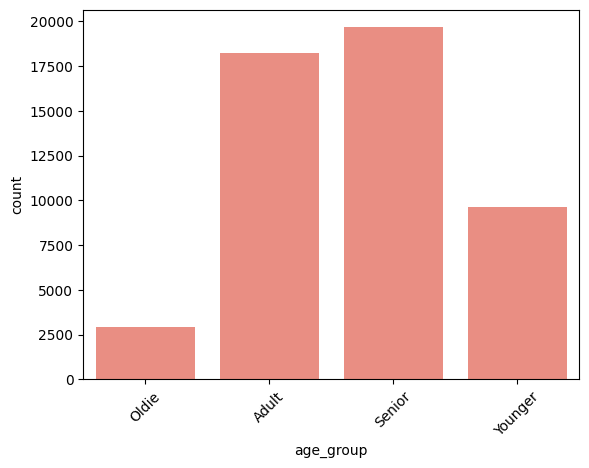

In [27]:
sns.countplot(x='age_group',  data=df, color='salmon')
plt.xticks(rotation=45)
plt.tight_layout
plt.show

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
round(df.groupby('age_group')['clnt_tenure_mnth'].mean().reset_index(),2)

,age_group,clnt_tenure_mnth
0,Adult,144.12
1,Oldie,204.90
2,Senior,167.49
3,Younger,110.93


<function matplotlib.pyplot.show(close=None, block=None)>

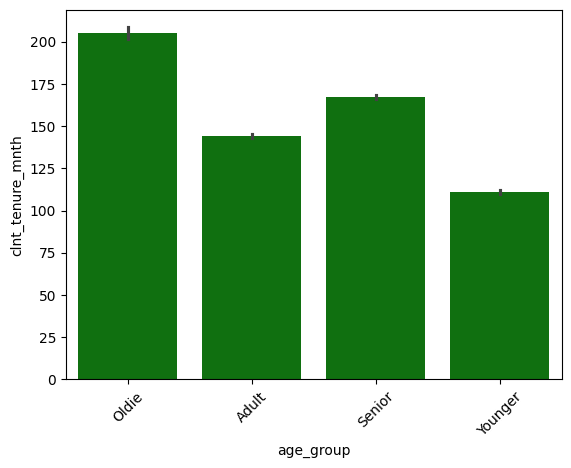

In [30]:
sns.barplot(x='age_group', y='clnt_tenure_mnth', data=df, color='green')
plt.xticks(rotation=45)
plt.tight_layout
plt.show

In [31]:
df_wd1.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [32]:
web = pd.concat([df_wd1, df_wd2], ignore_index=True) # Combine the two web data files into one dataframe.

In [33]:
web.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [34]:
web.shape

(755405, 5)

In [35]:
web.groupby('client_id')['process_step'].count().reset_index()


,client_id,process_step
0,169,5
1,336,2
2,546,5
3,555,5
4,647,5
...,...,...
120152,9999729,11
120153,9999768,12
120154,9999832,2
120155,9999839,6


In [36]:
from functions import process_step_counts
process_step_counts()


,process_step,count
0,start,243945
1,step_1,163193
2,step_2,133062
3,step_3,112242
4,confirm,102963


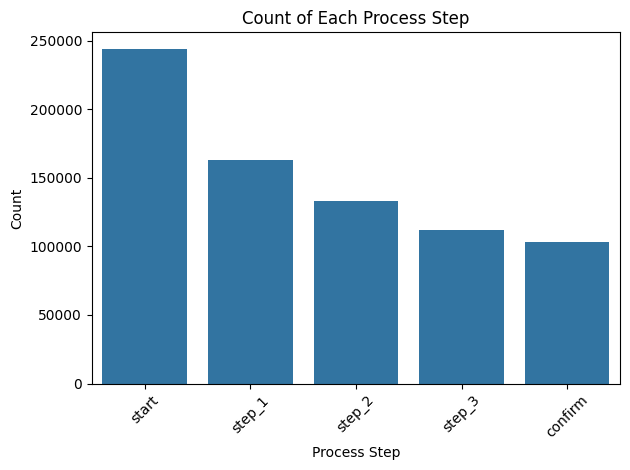

In [37]:
sns.barplot(x='process_step', y='count', data=process_step_counts())
plt.xticks(rotation=45)
plt.title('Count of Each Process Step')
plt.xlabel('Process Step')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [38]:
web.groupby("visit_id")["process_step"].count().reset_index()

,visit_id,process_step
0,100012776_37918976071_457913,2
1,1000165_4190026492_760066,5
2,100019538_17884295066_43909,11
3,100022086_87870757897_149620,5
4,100030127_47967100085_936361,1
...,...,...
158090,999986292_55082159911_561557,2
158091,999988789_76411676596_272843,5
158092,999989069_52203656268_170206,2
158093,999991142_15352368745_399725,1


**KPI and Matrix**

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_exp  = pd.read_csv('raw/df_final_experiment_clients.csv')
df_demo = pd.read_csv('raw/df_final_demo.csv')
df_wd1  = pd.read_csv('raw/df_final_web_data_pt_1.csv', parse_dates=['date_time'])
df_wd2  = pd.read_csv('raw/df_final_web_data_pt_2.csv', parse_dates=['date_time'])



In [40]:
web = pd.concat([df_wd1, df_wd2], ignore_index=True) # Combine the two web data files into one dataframe.

In [41]:
# After your concat
web = pd.concat([df_wd1, df_wd2], ignore_index=True)

# Save it
web.to_csv('raw/df_final_web_data.csv', index=False)

In [42]:
df_exp.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [43]:
web = web.merge(df_exp[['client_id', 'Variation']], on='client_id', how='left') # Merge the web data with the experiment data to get the variation for each client.

In [44]:
web.head()

,client_id,visitor_id,visit_id,process_step,date_time,Variation
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,Test
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,Test
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,Test


In [45]:
step_order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']
step_rank = {step: i for i, step in enumerate(step_order)}

In [46]:
web['step_rank'] = web['process_step'].map(step_rank)

Clients who have competed the last step till confirmation   

In [47]:
complete_step = web[web['process_step']=='confirm']['client_id'].unique()
complete_step

array([8320017, 4033851, 1982004, ..., 9563467, 9895983, 9668240],
      shape=(81145,))

In [48]:
all_clients = web[['client_id', 'Variation']].drop_duplicates()

In [49]:
all_clients['completed'] = all_clients['client_id'].isin(complete_step).astype(int)

In [50]:
completion = all_clients.groupby('Variation')['completed'].agg(['sum', 'count']).reset_index()
completion.columns = ['variation','completed', 'total']
completion['completion_rate'] = completion['completed'] / completion['total']
print(completion)

  variation  completed  total  completion_rate
0   Control      15434  23532         0.655873
1      Test      18687  26968         0.692932


**There is a 0.04 difference in completion in the old design and new design** 

Funnel analysis

In [51]:
visit_max = (
    web.groupby(['visit_id', 'Variation'])['step_rank'].max().reset_index().rename(columns={'step_rank': 'max_step_rank'})
)
visit_max

,visit_id,Variation,max_step_rank
0,100012776_37918976071_457913,Test,4
1,100019538_17884295066_43909,Test,4
2,100022086_87870757897_149620,Test,4
3,100030127_47967100085_936361,Control,0
4,100037962_47432393712_705583,Control,1
...,...,...,...
69320,999971096_28827267783_236076,Test,4
69321,999976049_95772503197_182554,Test,4
69322,999984454_18731538378_781808,Test,4
69323,999985675_64610694964_443659,Control,4


Control - start:  100.0%
Control - step_1:  76.5%
Control - step_2:  65.6%
Control - step_3:  59.3%
Control - confirm:  49.8%
Test - start:  100.0%
Test - step_1:  86.3%
Test - step_2:  75.8%
Test - step_3:  68.9%
Test - confirm:  58.5%


([<matplotlib.axis.XTick at 0x11de47110>,
 [Text(0, 0, 'start'),
  Text(1, 0, 'step_1'),
  Text(2, 0, 'step_2'),
  Text(3, 0, 'step_3'),
  Text(4, 0, 'confirm')])

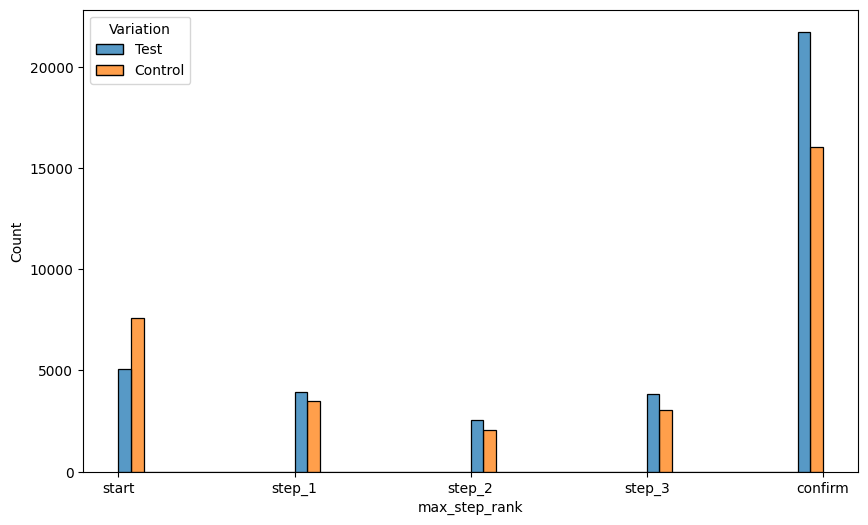

In [52]:
for variation in ['Control', 'Test']:
    subset = visit_max[visit_max['Variation'] == variation]
    total = len(subset)
    for step in step_order:
        rank = step_rank[step]
        reached = (subset['max_step_rank'] >= rank).sum()
        print(f"{variation} - {step}: {reached/total*100: .1f}%")

plt.figure(figsize=(10, 6))
sns.histplot(visit_max, x='max_step_rank', hue='Variation', multiple='dodge', shrink=1)
plt.xticks(range(len(step_order)), step_order)

Key takeaway

- The Test version improves retention across the entire funnel, reducing drop-off by roughly 8–10 percentage points at each stage.
- This suggests the Test changes are likely having a meaningful positive impact on user progression and completion.

**Time Spent per step**

In [53]:
web_sorted = web.sort_values(['visit_id', 'date_time'])
web_sorted

,client_id,visitor_id,visit_id,process_step,date_time,Variation,step_rank
108614,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:22:17,Test,4
108613,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:23:09,Test,4
447951,9056452,306992881_89423906595,1000165_4190026492_760066,start,2017-06-04 01:07:29,NaN,0
447950,9056452,306992881_89423906595,1000165_4190026492_760066,step_1,2017-06-04 01:07:32,NaN,1
447949,9056452,306992881_89423906595,1000165_4190026492_760066,step_2,2017-06-04 01:07:56,NaN,2
...,...,...,...,...,...,...,...
539055,7149380,483112224_46340533900,999992932_41666455053_671149,step_1,2017-06-06 15:46:24,NaN,1
539054,7149380,483112224_46340533900,999992932_41666455053_671149,step_2,2017-06-06 15:47:32,NaN,2
539072,7149380,483112224_46340533900,999992932_41666455053_671149,step_3,2017-06-06 16:01:46,NaN,3
539071,7149380,483112224_46340533900,999992932_41666455053_671149,confirm,2017-06-06 16:04:08,NaN,4


In [54]:
web_sorted['next_time'] = web_sorted.groupby('visit_id')['date_time'].shift(-1)
web_sorted['time_diff'] = (web_sorted['next_time'] - web_sorted['date_time']).dt.total_seconds()


In [55]:
time_data= web_sorted[
            (web_sorted['time_diff'] >= 0) &
            (web_sorted['time_diff'] <= 1800)] # 30 mins = 1800 seconds

In [56]:
time_summary = (time_data.groupby(['Variation', 'process_step'])['time_diff']).median().reset_index()

print(time_summary)

  Variation process_step  time_diff
0   Control      confirm       42.0
1   Control        start       18.0
2   Control       step_1       20.0
3   Control       step_2       64.0
4   Control       step_3       71.0
5      Test      confirm       91.0
6      Test        start       14.0
7      Test       step_1       27.0
8      Test       step_2       61.0
9      Test       step_3       57.0


**Error Rate**

A error rate would be when a user is going backwards to complete the infos e.g., going backward from step 3 to step 2

In [57]:
web_sorted['next_step'] = web_sorted.groupby('visit_id')['process_step'].shift(-1)
web_sorted['next_step_rank'] = web_sorted['next_step'].map(step_rank)

backward_data = web_sorted[
    (web_sorted['next_step_rank'] < web_sorted['step_rank']) ]

In [58]:
total_errors = (
    web_sorted[web_sorted['next_step'].notna()].groupby(['Variation', 'process_step']).size().reset_index(name='total_errors')  
)
total_errors

,Variation,process_step,total_errors
0,Control,confirm,2270
1,Control,start,37976
2,Control,step_1,26180
3,Control,step_2,24429
4,Control,step_3,20549
5,Test,confirm,4411
6,Test,start,47031
7,Test,step_1,35634
8,Test,step_2,29665
9,Test,step_3,24114


In [59]:
backward = backward_data.groupby(['Variation', 'process_step']).size().reset_index(name='backward_count')
backward

,Variation,process_step,backward_count
0,Control,confirm,859
1,Control,step_1,2503
2,Control,step_2,2167
3,Control,step_3,4253
4,Test,confirm,498
5,Test,step_1,6408
6,Test,step_2,4785
7,Test,step_3,4754


In [60]:
error_df = total_errors.merge(backward, on=['Variation', 'process_step'], how='left')


In [61]:
error_df['backward_count'] = error_df['backward_count'].fillna(0)
error_df['error_rate'] = error_df['backward_count'] / error_df['total_errors']
print(error_df)

  Variation process_step  total_errors  backward_count  error_rate
0   Control      confirm          2270           859.0    0.378414
1   Control        start         37976             0.0    0.000000
2   Control       step_1         26180          2503.0    0.095607
3   Control       step_2         24429          2167.0    0.088706
4   Control       step_3         20549          4253.0    0.206969
5      Test      confirm          4411           498.0    0.112900
6      Test        start         47031             0.0    0.000000
7      Test       step_1         35634          6408.0    0.179828
8      Test       step_2         29665          4785.0    0.161301
9      Test       step_3         24114          4754.0    0.197147


**Exporting Cleaned CSVs for Tableau**

In [62]:
# 1. Completion rate by group
completion.to_csv('tableau/completion_rate.csv', index=False)

# 2. Error rate by step and group
error_df.to_csv('tableau/error_rate.csv', index=False)

# 3. Demographics merged with experiment group
demographics = pd.merge(df_exp, df_demo, on='client_id', how='inner')
demographics.to_csv('tableau/demographics.csv', index=False)

# 4. Full web data with Variation (already merged in KPI notebook)
web.to_csv('tableau/web_with_variation.csv', index=False)

**Hypothesis**

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_exp  = pd.read_csv('raw/df_final_experiment_clients.csv')
df_demo = pd.read_csv('raw/df_final_demo.csv')
df_wd1  = pd.read_csv('raw/df_final_web_data_pt_1.csv', parse_dates=['date_time'])
df_wd2  = pd.read_csv('raw/df_final_web_data_pt_2.csv', parse_dates=['date_time'])

web = pd.read_csv('raw/df_final_web_data.csv', parse_dates=['date_time'])

In [64]:
import os
print(os.getcwd())

/Users/kanakyadav/Documents/GitHub/Ironhack_second_project


**A/B Hypothesis - Testing**



**1. *Hypothesis 1:* Completion Rate**

   Did the new interface increase the completion rate?

   - H0: completion rate of the steps between control group(A) and test group(B) is **similar**
   - H1: completion rate of the steps between control group(A) and test group(B) is **different**

In [65]:
completed = (
    web.groupby('client_id')['process_step']
    .apply(lambda steps: 'confirm' in steps.values)
    .reset_index()
    .rename(columns={'process_step': 'completed'})
)

In [66]:
df_hyp = df_exp.merge(completed, on='client_id', how='inner')

**The significance value, apha = 0.05**

In [67]:
completion_by_group = df_hyp.groupby('Variation')['completed'].agg(['sum', 'count'])
completion_by_group['rate'] = completion_by_group['sum'] / completion_by_group['count']
print(completion_by_group)

             sum  count      rate
Variation                        
Control    15434  23532  0.655873
Test       18687  26968  0.692932


In [68]:
from statsmodels.stats.proportion import proportions_ztest

control = df_hyp[df_hyp['Variation'] == 'Control']
test    = df_hyp[df_hyp['Variation'] == 'Test']

counts = [control['completed'].sum(), test['completed'].sum()]
nobs   = [len(control), len(test)]

z_stat, p_value = proportions_ztest(counts, nobs)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value:     {p_value:.20f}")

Z-statistic: -8.8745
P-value:     0.00000000000000000070


In [69]:
alpha = 0.05
if p_value < alpha:
    print("Reject H0 — completion rates are significantly different.")
else:
    print("Fail to reject H0 — no significant difference found.")

Reject H0 — completion rates are significantly different.


***Hypothesis 2*: Average Age similarity (Cost-Effectiveness Check)**

Was the experiment group assignment demographically fair?

- H0: Average age of Control and Test groups is **similar**
- H1: Average age of Control and Test groups is **different**

In [70]:
df_demo_exp = df_exp.merge(df_demo, on='client_id', how='inner')

In [71]:
control_age = df_demo_exp[df_demo_exp['Variation'] == 'Control']['clnt_age']
test_age    = df_demo_exp[df_demo_exp['Variation'] == 'Test']['clnt_age']

print("Control mean age:", control_age.mean().round(2))
print("Test mean age:   ", test_age.mean().round(2))

Control mean age: 47.5
Test mean age:    47.16


**The significance value, apha = 0.05**

In [72]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(control_age, test_age, nan_policy='omit')

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

T-statistic: 2.4161
P-value:     0.0157


In [73]:
alpha = 0.05
if p_value < alpha:
    print("Reject H0 — age distributions are significantly different (potential bias)")
else:
    print("Fail to reject H0 — groups are demographically similar in age (fair split)")

Reject H0 — age distributions are significantly different (potential bias)


**Interpretation**

Statistically → Reject H0 (p = 0.016 < 0.05)

Practically → 0.34 years difference is essentially nothing. That's 4 months difference in average age between groups — completely negligible for a financial services experiment.


In [74]:
print("Control mean age:", control_age.mean().round(2))
print("Test mean age:   ", test_age.mean().round(2))
print("Difference:      ", abs(control_age.mean() - test_age.mean()).round(2), "years")

Control mean age: 47.5
Test mean age:    47.16
Difference:       0.33 years


The t-test returns a statistically significant result (**p = 0.016**), however the actual difference in mean age is only **0.34 years** (47.50 vs 47.16). This is practically insignificant and confirms the experiment groups are demographically balanced in terms of age. The randomization was fair.

***Hypothesis 3*: Time Spent on Steps**

Did the new interface help users move through steps faster?

- H0: Median time per step is **similar** between groups
- H1: Median time per step is **different** between groups

In [75]:
web = web.sort_values(['visit_id', 'date_time'])
web['time_on_step'] = web.groupby('visit_id')['date_time'].diff().shift(-1)
web['time_on_step_sec'] = web['time_on_step'].dt.total_seconds()

# Cap outliers
cap = web['time_on_step_sec'].quantile(0.95)
web['time_on_step_capped'] = web['time_on_step_sec'].clip(upper=cap)

In [76]:
df_web_exp = web.merge(df_exp, on='client_id', how='inner')

In [77]:
control_time = df_web_exp[df_web_exp['Variation'] == 'Control']['time_on_step_capped'].dropna()
test_time    = df_web_exp[df_web_exp['Variation'] == 'Test']['time_on_step_capped'].dropna()

# Verify, there are no nulls left
print("Control nulls after drop:", control_time.isna().sum())
print("Test nulls after drop:   ", test_time.isna().sum())


Control nulls after drop: 0
Test nulls after drop:    0


In [78]:
print("Control median time (sec):", control_time.median().round(2))
print("Test median time (sec):   ", test_time.median().round(2))

Control median time (sec): 35.0
Test median time (sec):    34.0


**The significance value, apha = 0.05**

In [79]:
from scipy.stats import mannwhitneyu

u_stat, p_value = mannwhitneyu(control_time, test_time, alternative='two-sided')

print(f"U-statistic: {u_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

U-statistic: 7829845182.5000
P-value:     0.3765


Why we choose U-test not t-test?

- T-test would compare means → heavily influenced by that long tail → misleading result
- Mann-Whitney U compares rank order of values → not affected by the skew → more honest result

- *mean:  64.88*
- *50%:   35.00*   ← median is much lower than mean
- *max:   307.00*  ← even after capping at 95th percentile!

In [80]:
alpha = 0.05
if p_value < alpha:
    print("Reject H0 — time spent on steps is significantly different between groups")
else:
    print("Fail to reject H0 — no significant difference in time spent")

Fail to reject H0 — no significant difference in time spent


After cleaning null values, the median time on steps is nearly identical: **35.0 sec (Control) vs 34.0 sec (Test)**. Mann-Whitney U test confirms no statistically significant difference (**p = 0.3765**). The new interface did not meaningfully change the time users spent on each step.